# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.81MB/s]

Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [5]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1822  train_acc=94.29%  test_loss=0.0636  test_acc=97.95%
Epoch 2/5  train_loss=0.0652  train_acc=98.05%  test_loss=0.0557  test_acc=98.19%
Epoch 3/5  train_loss=0.0494  train_acc=98.49%  test_loss=0.0408  test_acc=98.77%
Epoch 4/5  train_loss=0.0423  train_acc=98.68%  test_loss=0.0497  test_acc=98.52%
Epoch 5/5  train_loss=0.0370  train_acc=98.81%  test_loss=0.0417  test_acc=98.62%


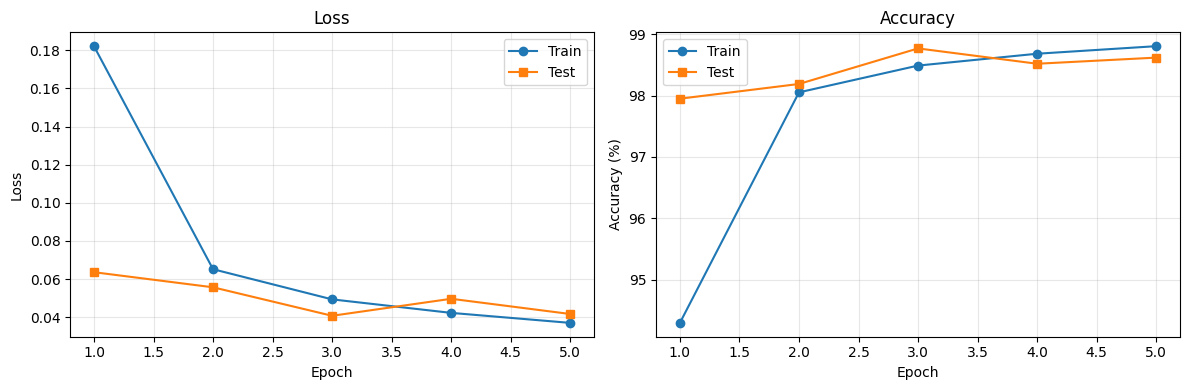

In [6]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [7]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.62%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

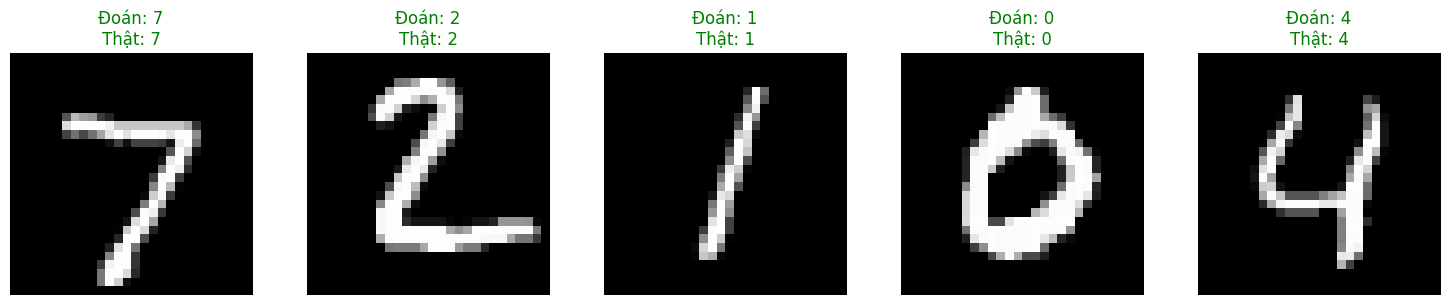

In [8]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

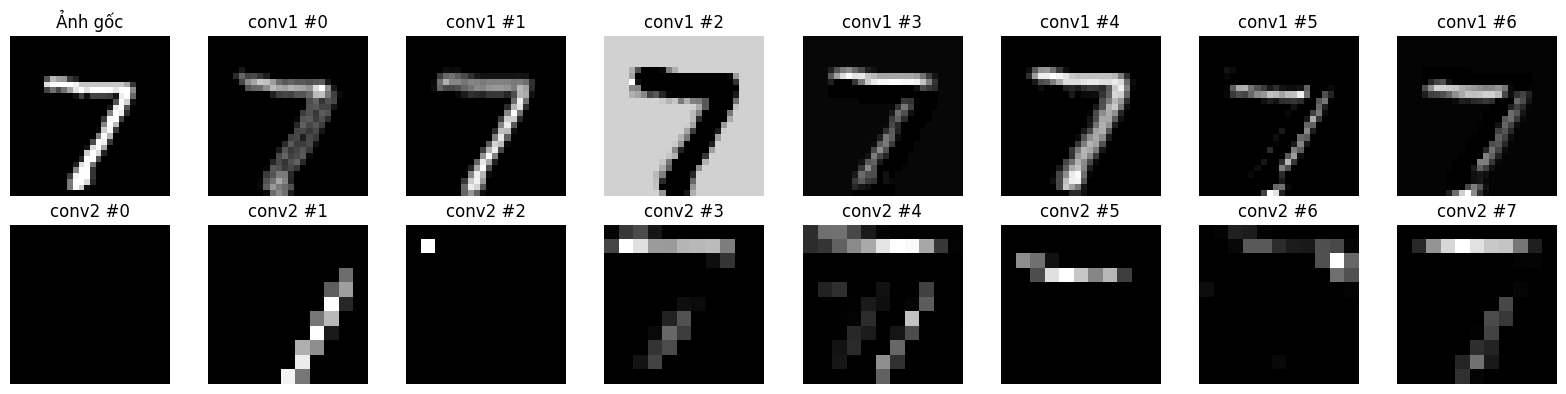

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [9]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

In [10]:
model_c1 = MNIST_CNN().to(device)
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

train_acc_hist, test_acc_hist = [], []

for epoch in range(10):
    model_c1.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_c1.zero_grad()
        outputs = model_c1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c1.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    _, test_acc = evaluate(model_c1, test_loader)
    train_acc_hist.append(correct / total)
    test_acc_hist.append(test_acc)
    print(f"Epoch {epoch+1:2d}/10 | Train Acc: {correct/total*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

Epoch  1/10 | Train Acc: 95.00% | Test Acc: 98.08%
Epoch  2/10 | Train Acc: 98.19% | Test Acc: 98.43%
Epoch  3/10 | Train Acc: 98.57% | Test Acc: 98.69%
Epoch  4/10 | Train Acc: 98.83% | Test Acc: 99.00%
Epoch  5/10 | Train Acc: 98.98% | Test Acc: 98.84%
Epoch  6/10 | Train Acc: 99.12% | Test Acc: 98.75%
Epoch  7/10 | Train Acc: 99.13% | Test Acc: 99.02%
Epoch  8/10 | Train Acc: 99.30% | Test Acc: 99.01%
Epoch  9/10 | Train Acc: 99.33% | Test Acc: 98.87%
Epoch 10/10 | Train Acc: 99.40% | Test Acc: 98.97%


Chênh lệch Test Accuracy (E10 so với E5):** Chênh lệch giữa hai epoch này là rất nhỏ. Lý do là mô hình CNN hội tụ trên MNIST rất nhanh, hiệu năng đạt đỉnh bão hòa ngay từ các epoch đầu.

Khoảng cách Train_Acc - Test_Acc Khoảng cách (Gap) này mở rộng dần từ Epoch 5 đến Epoch 10. Trong khi Train Acc tiến gần sát mức tuyệt đối thì Test Acc có xu hướng đi ngang. Đây chính là dấu hiệu của hiện tượng
**Overfitting** khi mạng bắt đầu "học thuộc lòng" các chi tiết nhiễu riêng biệt của tập dữ liệu huấn luyện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

In [11]:
class DeeperCNN_Homework(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # -> (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))  # -> (32, 5, 5)
        x = self.pool(torch.relu(self.conv3(x)))  # -> (64, 2, 2)
        x = x.view(x.size(0), -1)
        return self.fc1(x)

model_c2 = DeeperCNN_Homework().to(device)
optimizer_c2 = optim.SGD(model_c2.parameters(), lr=0.01, momentum=0.9)

for epoch in range(5):
    model_c2.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_c2.zero_grad()
        loss = criterion(model_c2(images), labels)
        loss.backward()
        optimizer_c2.step()
    _, test_acc = evaluate(model_c2, test_loader)
    print(f"Deeper CNN - Epoch {epoch+1}/5 | Test Acc: {test_acc*100:.2f}%")

Deeper CNN - Epoch 1/5 | Test Acc: 98.14%
Deeper CNN - Epoch 2/5 | Test Acc: 98.59%
Deeper CNN - Epoch 3/5 | Test Acc: 98.96%
Deeper CNN - Epoch 4/5 | Test Acc: 98.92%
Deeper CNN - Epoch 5/5 | Test Acc: 99.10%



Việc xếp chồng thêm tầng tích chập `conv3` giúp mạng CNN tăng khả năng trích xuất các tổ hợp đặc trưng ở cấp độ cao và phức tạp hơn.


## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

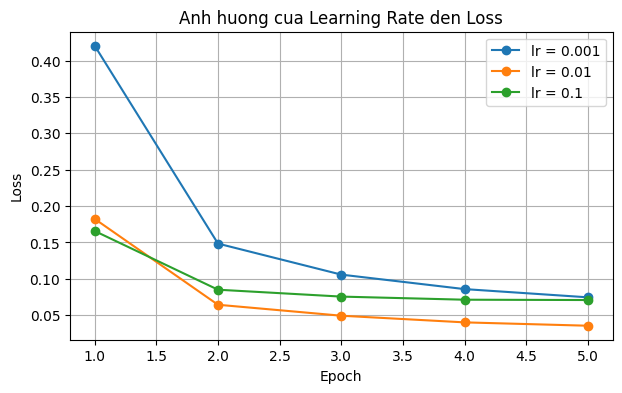

In [12]:
lrs = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in lrs:
    m_lr = MNIST_CNN().to(device)
    opt_lr = optim.SGD(m_lr.parameters(), lr=lr, momentum=0.9)

    hist = []
    for epoch in range(5):
        m_lr.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt_lr.zero_grad()
            loss = criterion(m_lr(images), labels)
            loss.backward()
            opt_lr.step()
            running_loss += loss.item() * images.size(0)
        hist.append(running_loss / len(train_dataset))
    lr_histories[lr] = hist

#Vẽ đồ thị so sánh
plt.figure(figsize=(7, 4))
for lr, hist in lr_histories.items():
    plt.plot(range(1, 6), hist, marker='o', label=f'lr = {lr}')
plt.title('Anh huong cua Learning Rate den Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()


lr = 0.001 (Quá thấp): Tốc độ học quá chậm, các bước cập nhật trọng số ngắn làm đường loss giảm rất thoải và tốn nhiều thời gian.

lr = 0.01 (Lý tưởng): Loss lao dốc mượt mà, nhanh chóng đi sâu xuống đáy hàm mất mát và hội tụ ổn định.

lr = 0.1 (Quá cao): Bước nhảy trọng số quá lớn khiến mô hình liên tục  dẫn đến đồ thị loss bị răng cưa, dao động mạnh hoặc bùng nổ mất kiểm soát.

Learning rate quyết định kích thước bước đi trên bề mặt đạo hàm. Chọn LR chính xác giúp cân bằng giữa tốc độ hội tụ nhanh và độ ổn định toán học của mô hình.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

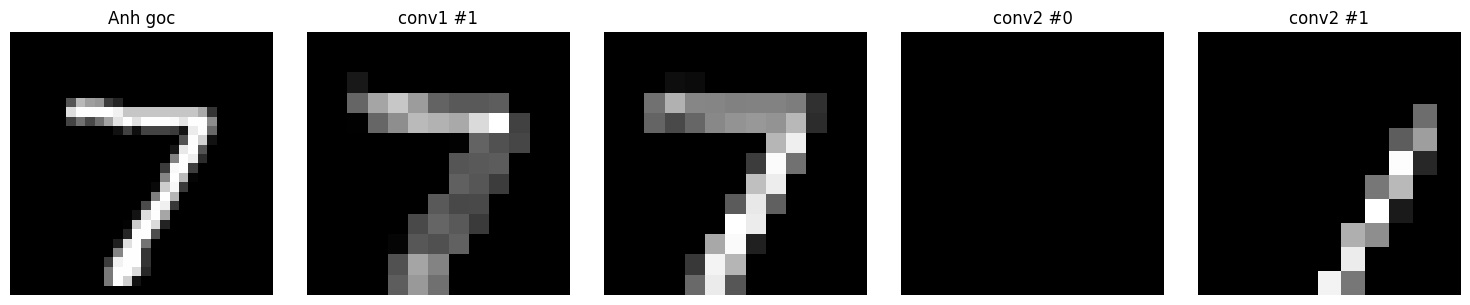

In [15]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0].set_title('Anh goc'); axes[0].axis('off')

axes[1].imshow(h1[0, 0].cpu(), cmap='gray'); axes[1].set_title('conv1 #0'); axes[1].axis('off')
axes[2].imshow(h1[0, 1].cpu(), cmap='gray'); axes[1].set_title('conv1 #1'); axes[2].axis('off')

axes[3].imshow(h2[0, 0].cpu(), cmap='gray'); axes[3].set_title('conv2 #0'); axes[3].axis('off')
axes[4].imshow(h2[0, 1].cpu(), cmap='gray'); axes[4].set_title('conv2 #1'); axes[4].axis('off')
plt.tight_layout(); plt.show()


Feature map của conv1: Hiển thị rất cụ thể, trực quan, dễ dàng nhận dạng ra các đường viền, nét gạch dọc hoặc gạch ngang thô của chữ số gốc. Tầng này chịu trách nhiệm bắt các đặc trưng hình học cơ bản.

Feature map của conv2: Trông mờ nhòe, trừu tượng và khó nhận diện bằng mắt người hơn rất nhiều. Do nằm sâu hơn và đã qua bộ lọc pooling, các pixel ở đây biểu diễn các tổ hợp đặc trưng phức tạp ở cấp độ cao  như cấu trúc mảng, góc bo tròn, giúp mô hình phân biệt sâu các chữ số viết tay mang tính biến dạng cao.

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

In [16]:
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

class DropoutCNN_Homework(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        return self.fc1(x)

model_c5 = DropoutCNN_Homework().to(device)
optimizer_c5 = optim.SGD(model_c5.parameters(), lr=0.01, momentum=0.9)

print("Huấn luyện CNN tích hợp Dropout + Data Augmentation (10 epochs):")
for epoch in range(10):
    model_c5.train()
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_c5.zero_grad()
        loss = criterion(model_c5(images), labels)
        loss.backward()
        optimizer_c5.step()
    _, test_acc = evaluate(model_c5, test_loader)
    print(f"Epoch {epoch+1:2d}/10 | Test Accuracy: {test_acc*100:.2f}%")

Huấn luyện CNN tích hợp Dropout + Data Augmentation (10 epochs):
Epoch  1/10 | Test Accuracy: 97.42%
Epoch  2/10 | Test Accuracy: 98.49%
Epoch  3/10 | Test Accuracy: 98.73%
Epoch  4/10 | Test Accuracy: 98.81%
Epoch  5/10 | Test Accuracy: 99.01%
Epoch  6/10 | Test Accuracy: 98.88%
Epoch  7/10 | Test Accuracy: 98.93%
Epoch  8/10 | Test Accuracy: 99.13%
Epoch  9/10 | Test Accuracy: 99.13%
Epoch 10/10 | Test Accuracy: 99.09%


Dropout giúp giảm overfitting bằng cách: Ngẫu nhiên ngắt bỏ $25\%$ lượng neuron kích hoạt ở lớp ẩn trong mỗi lượt train. Điều này ép mô hình phải tìm ra các đường truyền tín hiệu tổng quát và độc lập hơn.

Data Augmentation giúp giảm overfitting bằng cách: Chủ động xoay nhẹ ảnh ($10^\circ$) và dịch chuyển tịnh tiến ($10\%$). Nó kìm hãm mạng không thể học vẹt một vị trí pixel cố định, giúp mô hình đạt độ tổng quát hóa vượt trội và chạy ổn định.